# EEG Cognitive State Data Exploration

This notebook helps you explore the raw and processed EEG data for the cognitive state classification project.

## Section 1: Import Required Libraries

We'll import pandas for data handling, matplotlib for plotting, and numpy for numerical operations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up matplotlib for inline plotting in Jupyter
%matplotlib inline
plt.style.use('default')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Load the EEG Recording CSV

Let's load a sample EEG recording file to see the raw data structure.

In [2]:
# Load EEG data from one subject
eeg_path = Path("../Data/raw/Experiment_1/A1/EEG_recording.csv")
eeg_df = pd.read_csv(eeg_path)

print(f"EEG data shape: {eeg_df.shape}")
print(f"Columns: {list(eeg_df.columns)}")
print("\nFirst 5 rows:")
eeg_df.head()

EEG data shape: (1298136, 6)
Columns: ['timestamps', 'TP9', 'AF7', 'AF8', 'TP10', 'Right AUX']

First 5 rows:


,timestamps,TP9,AF7,AF8,TP10,Right AUX
0,1.624262e+09,34.180,50.781,34.180,-26.367,5.371
1,1.624262e+09,49.316,50.781,20.996,-8.789,-12.207
2,1.624262e+09,50.293,10.742,15.137,-2.441,-27.832
3,1.624262e+09,44.922,-19.043,16.602,-23.926,-33.203
4,1.624262e+09,19.531,20.020,31.250,-48.340,-30.273


## Section 3: Inspect Raw and Processed Data Columns

The EEG data has timestamps and 4 main channels (TP9, AF7, AF8, TP10) plus an auxiliary channel.

In [ ]:
# Inspect data types and missing values
print("Data types:")
print(eeg_df.dtypes)
print(f"\nMissing values per column:\n{eeg_df.isnull().sum()}")

# EEG channels
eeg_channels = ['TP9', 'AF7', 'AF8', 'TP10']
print(f"\nEEG channels: {eeg_channels}")

# Check sampling rate (Muse headband is 256 Hz)
time_diff = eeg_df['timestamps'].diff().mean()
sampling_rate = 1 / time_diff
print(f"Sampling interval mean: {time_diff:.6f} s, sampling rate ~{sampling_rate:.1f} Hz")

Data types:
timestamps    float64
TP9           float64
AF7           float64
AF8           float64
TP10          float64
Right AUX     float64
dtype: object

Missing values per column:
timestamps    0
TP9           0
AF7           0
AF8           0
TP10          0
Right AUX     0
dtype: int64

EEG channels: ['TP9', 'AF7', 'AF8', 'TP10']
.2f


## Section 4: Summarize Key Metrics

Let's compute basic statistics for the EEG channels.

In [4]:
# Basic statistics for EEG channels
print("EEG Channel Statistics:")
stats = eeg_df[eeg_channels].describe()
stats

EEG Channel Statistics:


,TP9,AF7,AF8,TP10
count,1.298136e+06,1.298136e+06,1.298136e+06,1.298136e+06
mean,3.165144e+01,3.432355e+01,3.265584e+01,2.302151e+01
std,1.301369e+02,1.372584e+02,1.137308e+02,1.572454e+02
min,-1.000000e+03,-1.000000e+03,-1.000000e+03,-1.000000e+03
25%,1.464800e+01,2.734400e+01,2.441400e+01,9.766000e+00
50%,3.271500e+01,3.710900e+01,3.564500e+01,2.832000e+01
75%,5.127000e+01,4.687500e+01,4.589800e+01,4.687500e+01
max,9.995120e+02,9.995120e+02,9.995120e+02,9.995120e+02


## Section 5: Plot Signal Channels

Let's visualize a short segment of the EEG signals.

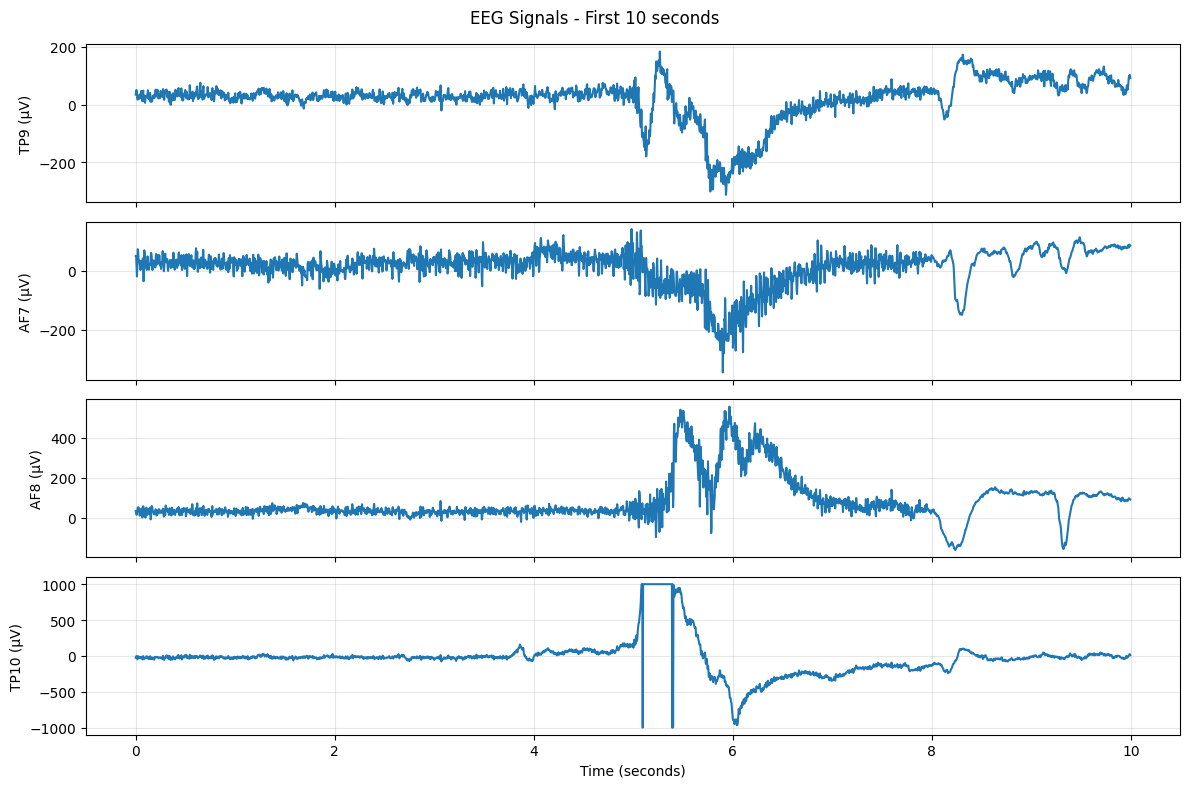

In [5]:
# Plot a 10-second segment of EEG data
start_idx = 0
duration_sec = 10
samples = int(duration_sec * sampling_rate)
end_idx = min(start_idx + samples, len(eeg_df))

fig, axes = plt.subplots(len(eeg_channels), 1, figsize=(12, 8), sharex=True)
time_axis = eeg_df['timestamps'].iloc[start_idx:end_idx] - eeg_df['timestamps'].iloc[start_idx]

for i, ch in enumerate(eeg_channels):
    axes[i].plot(time_axis, eeg_df[ch].iloc[start_idx:end_idx])
    axes[i].set_ylabel(f'{ch} (µV)')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle(f'EEG Signals - First {duration_sec} seconds')
plt.tight_layout()
plt.show()

## Section 6: Explore Processed Data

Now let's look at the processed features and labels.

In [ ]:
# Load processed data
X = np.load("../Data/processed/X_features.npy")
y = np.load("../Data/processed/y_labels.npy")

print(f"Processed dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

# Label distribution
unique, counts = np.unique(y, return_counts=True)
state_names = {0: 'Fatigued', 1: 'Impulsive', 2: 'Careful', 3: 'Focused'}
print("\nLabel distribution:")
for label, count in zip(unique, counts):
    pct = 100 * count / len(y)
    print(f'  {state_names[label]}: {count} samples ({pct:.1f}%)')

# Feature statistics
print(f"\nFeature statistics (first 10 features):")
feature_stats = pd.DataFrame({
    'mean': X.mean(axis=0)[:10],
    'std': X.std(axis=0)[:10],
    'min': X.min(axis=0)[:10],
    'max': X.max(axis=0)[:10]
})
feature_stats

Processed dataset shape: (7185, 53)
Number of samples: 7185
Number of features: 53

Label distribution:
.1f
.1f
.1f
.1f

Feature statistics (first 10 features):


,mean,std,min,max
0,356.887024,1151.011963,0.764158,60808.210938
1,250.888657,724.921814,1.984632,32860.394531
2,35.733002,181.683411,1.311042,10359.500000
3,28.128416,145.266632,2.091975,8838.443359
4,19.244959,99.111832,0.508637,6030.514160
5,32.478016,21.408846,-398.853455,640.024109
6,41.082783,36.522427,5.518524,818.899414
7,-1.275229,1.264736,-7.496574,4.305995
8,5.691097,5.323323,-1.667376,60.545418
9,3021.682617,13445.763672,30.454111,670596.187500


## Section 7: Using Jupyter Notebooks

This notebook demonstrates basic Jupyter usage:

- **Markdown cells** (like this one) for documentation and explanations
- **Code cells** for executing Python code
- **Inline plots** with `%matplotlib inline`
- **Interactive exploration** - you can modify and re-run cells

**Tips:**
- Press Shift+Enter to run a cell
- Use the toolbar to add/delete cells
- Cells can be run in any order, but outputs update sequentially
- Save your work with Ctrl+S

Try modifying the plotting code above to visualize different time segments or channels!

## Section 8: Visualize Cognitive State Distributions

Let's explore how the 4 cognitive states relate to the EEG features.

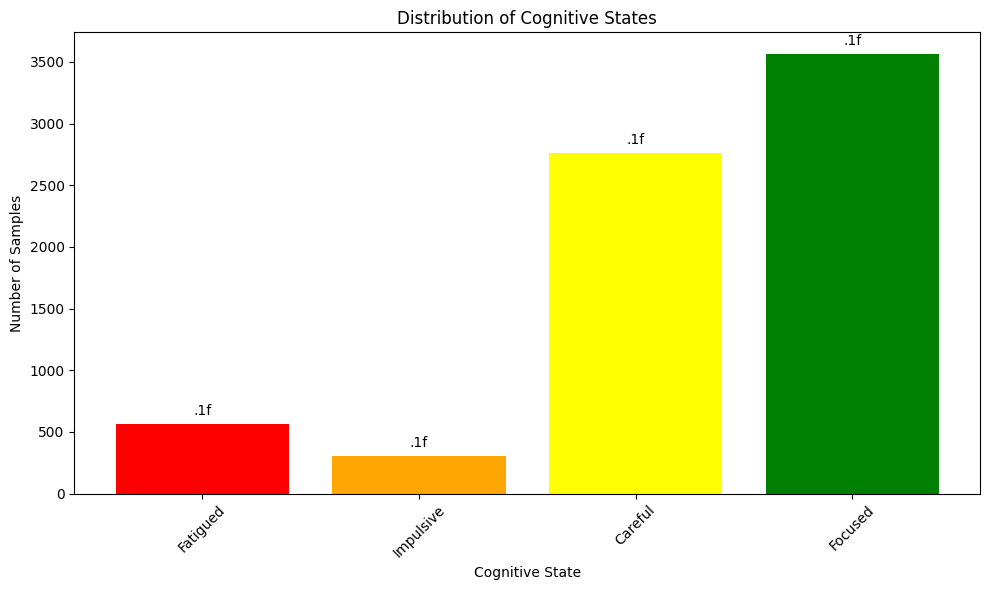

In [ ]:
# Label distribution visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(state_names.values(), counts, color=['red', 'orange', 'yellow', 'green'])
plt.title('Distribution of Cognitive States')
plt.xlabel('Cognitive State')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

# Add percentage labels
for bar, pct in zip(bars, [100*c/len(y) for c in counts]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{pct:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Section 9: Feature Analysis by Cognitive State

Let's examine how specific EEG features differ across cognitive states. We'll look at some key features like theta/beta ratio and alpha power.

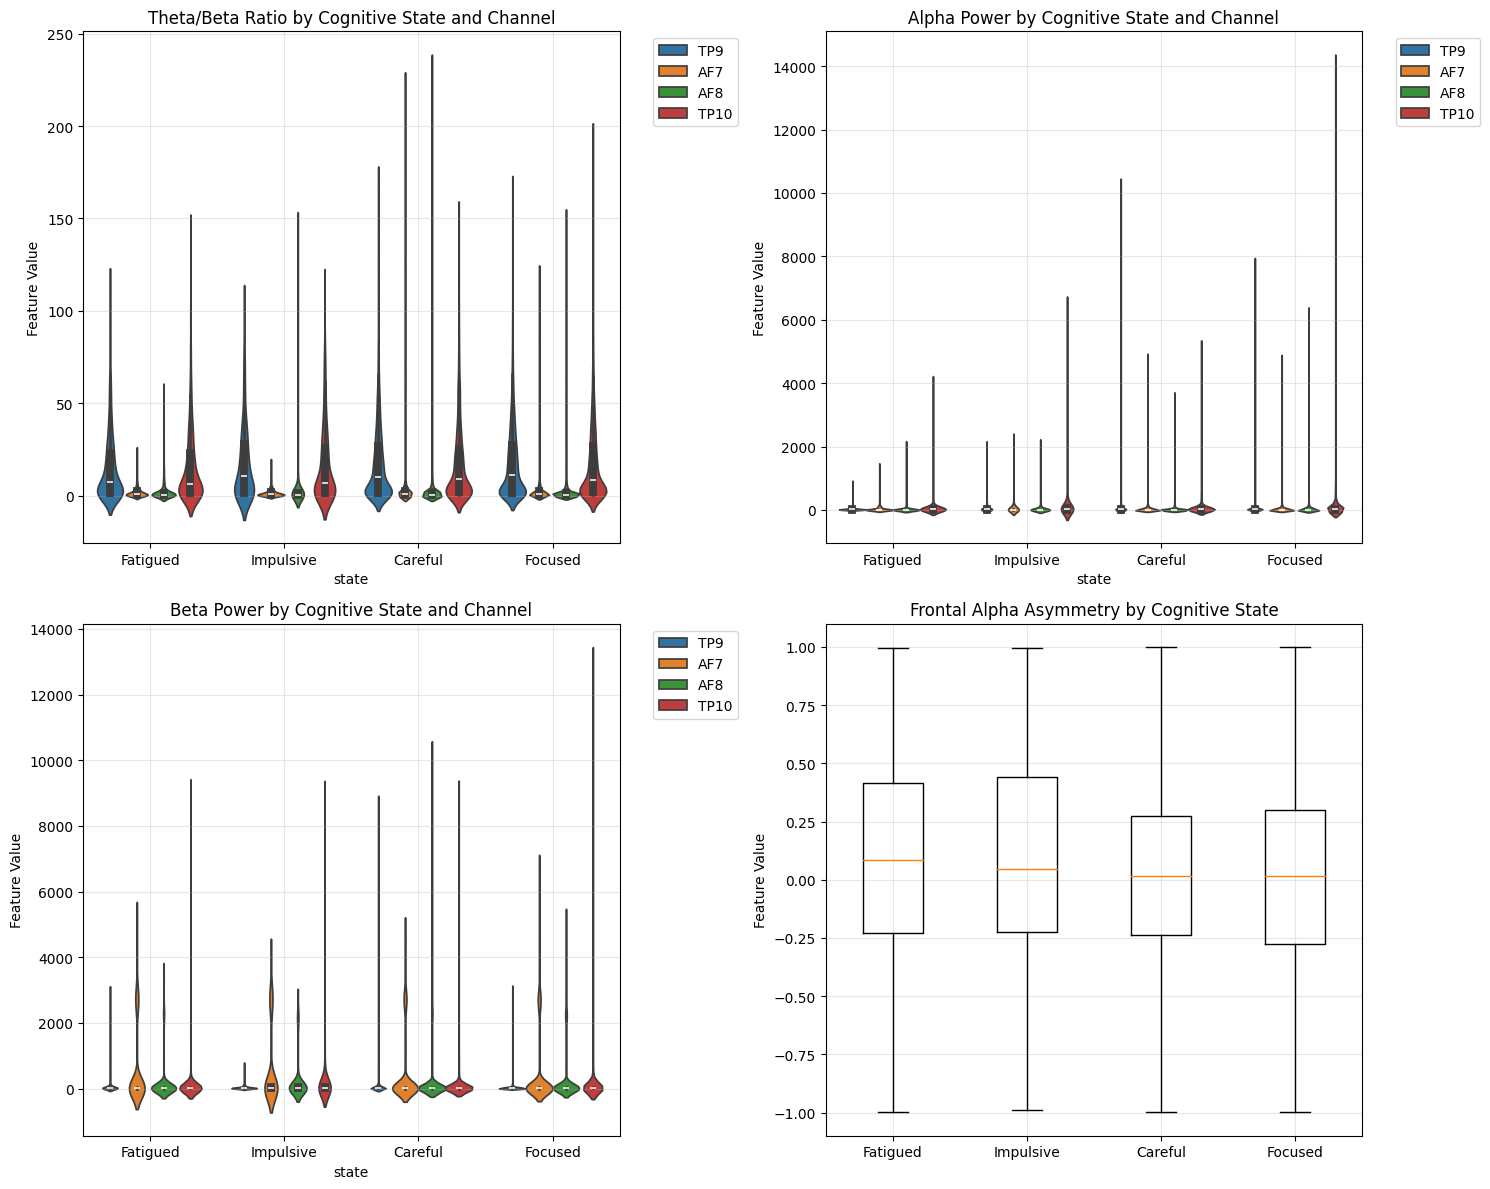

In [8]:
# Feature indices (from preprocessing.py)
# Each channel has 13 features: delta, theta, alpha, beta, gamma, mean, std, skew, kurt, activity, mobility, complexity, tbr
# Channels: TP9(0-12), AF7(13-25), AF8(26-38), TP10(39-51), asymmetry(52)

feature_names = []
channels = ['TP9', 'AF7', 'AF8', 'TP10']
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
stats = ['mean', 'std', 'skew', 'kurt', 'activity', 'mobility', 'complexity', 'tbr']

for ch in channels:
    for band in bands:
        feature_names.append(f'{ch}_{band}')
    for stat in stats:
        feature_names.append(f'{ch}_{stat}')
feature_names.append('frontal_alpha_asymmetry')

# Select some key features to compare
key_features = {
    'Theta/Beta Ratio': [12, 25, 38, 51],  # TBR for each channel
    'Alpha Power': [2, 15, 28, 41],       # Alpha for each channel
    'Beta Power': [3, 16, 29, 42],        # Beta for each channel
    'Frontal Alpha Asymmetry': [52]
}

# Create box plots for each key feature group
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (feature_group, indices) in enumerate(key_features.items()):
    ax = axes[i]

    # Prepare data for box plot
    plot_data = []
    labels = []

    for idx in indices:
        if idx < X.shape[1]:
            for state in [0, 1, 2, 3]:
                mask = y == state
                plot_data.append(X[mask, idx])
                if len(indices) > 1:
                    labels.append(f'{state_names[state]}\n{feature_names[idx]}')
                else:
                    labels.append(state_names[state])

    if len(indices) == 1:
        # Single feature
        ax.boxplot(plot_data, labels=[state_names[state] for state in [0,1,2,3]])
        ax.set_title(f'{feature_group} by Cognitive State')
    else:
        # Multiple features - use violin plot for better visualization
        import seaborn as sns
        data_for_plot = []
        for state in [0,1,2,3]:
            for idx in indices:
                mask = y == state
                data_for_plot.extend([{'value': val, 'state': state_names[state], 'channel': feature_names[idx].split('_')[0]}
                                    for val in X[mask, idx]])

        df_plot = pd.DataFrame(data_for_plot)
        sns.violinplot(data=df_plot, x='state', y='value', hue='channel', ax=ax)
        ax.set_title(f'{feature_group} by Cognitive State and Channel')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.set_ylabel('Feature Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 10: Dimensionality Reduction and Clustering

Let's use PCA and t-SNE to see if the cognitive states form distinct clusters in feature space.

PCA explained variance ratio: [0.21122384 0.16605791]
.3f


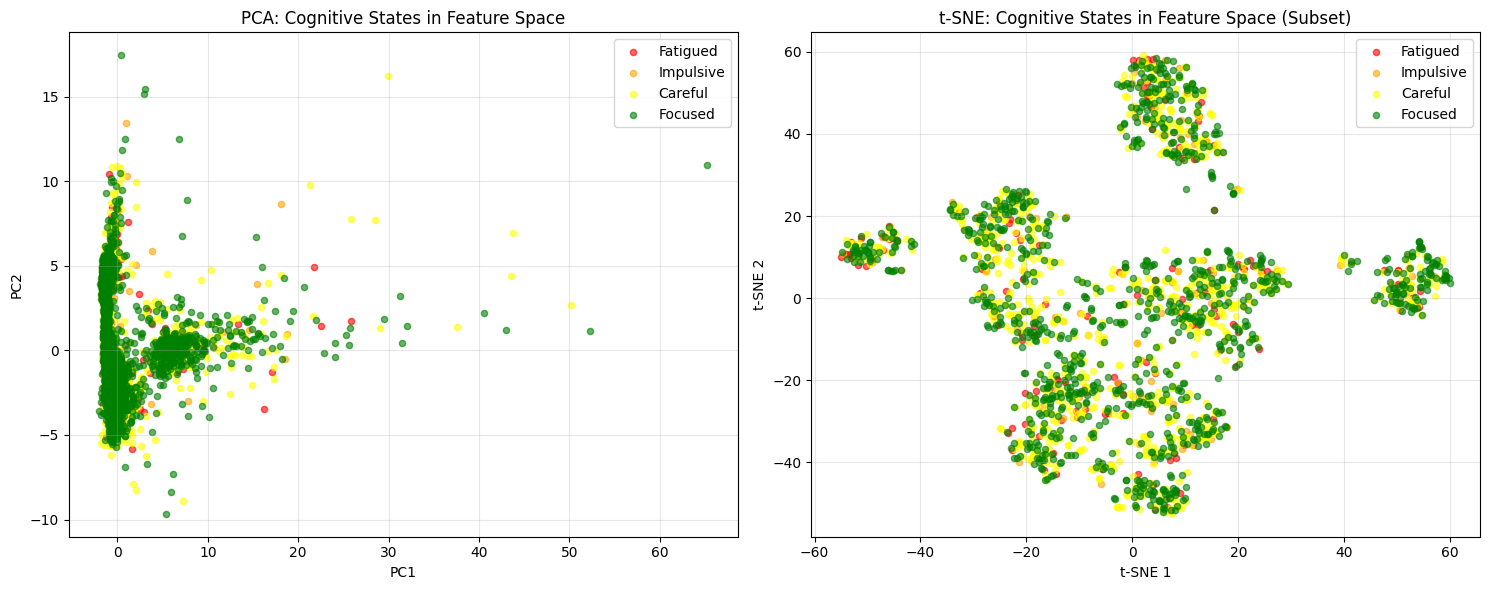

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Standardize features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f'PCA total explained variance: {pca.explained_variance_ratio_.sum():.3f}')

# t-SNE (take a subset for speed)
np.random.seed(42)
subset_size = min(2000, len(X))
subset_indices = np.random.choice(len(X), subset_size, replace=False)
X_subset = X_scaled[subset_indices]
y_subset = y[subset_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_subset)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA plot
colors = ['red', 'orange', 'yellow', 'green']
for state in [0, 1, 2, 3]:
    mask = y == state
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[state],
                   label=state_names[state], alpha=0.6, s=20)
axes[0].set_title('PCA: Cognitive States in Feature Space')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE plot
for state in [0, 1, 2, 3]:
    mask = y_subset == state
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[state],
                   label=state_names[state], alpha=0.6, s=20)
axes[1].set_title('t-SNE: Cognitive States in Feature Space (Subset)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 11: Feature Correlations and Importance

Let's examine which features are most correlated with cognitive states and create a correlation heatmap.

Top 20 features most correlated with cognitive state:
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s
6s


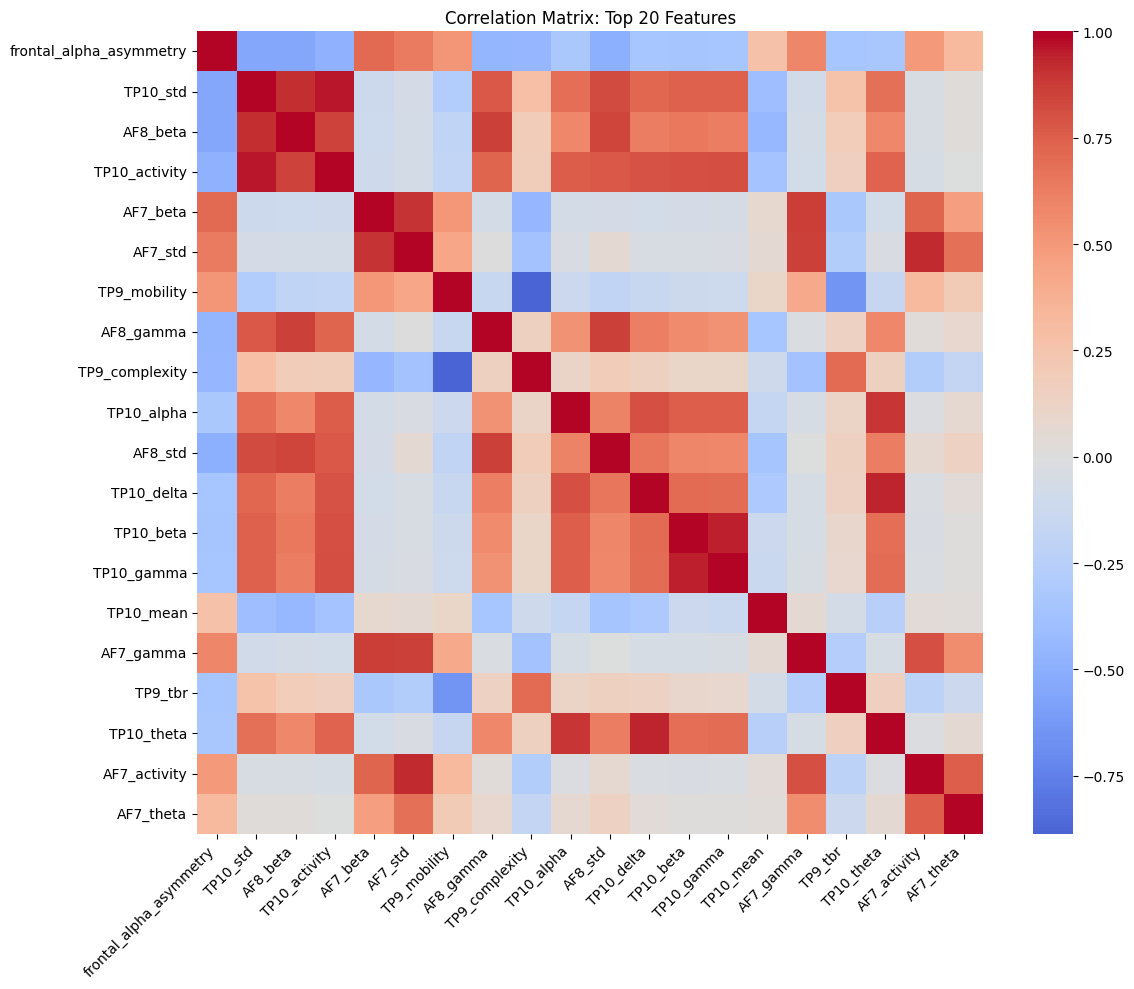

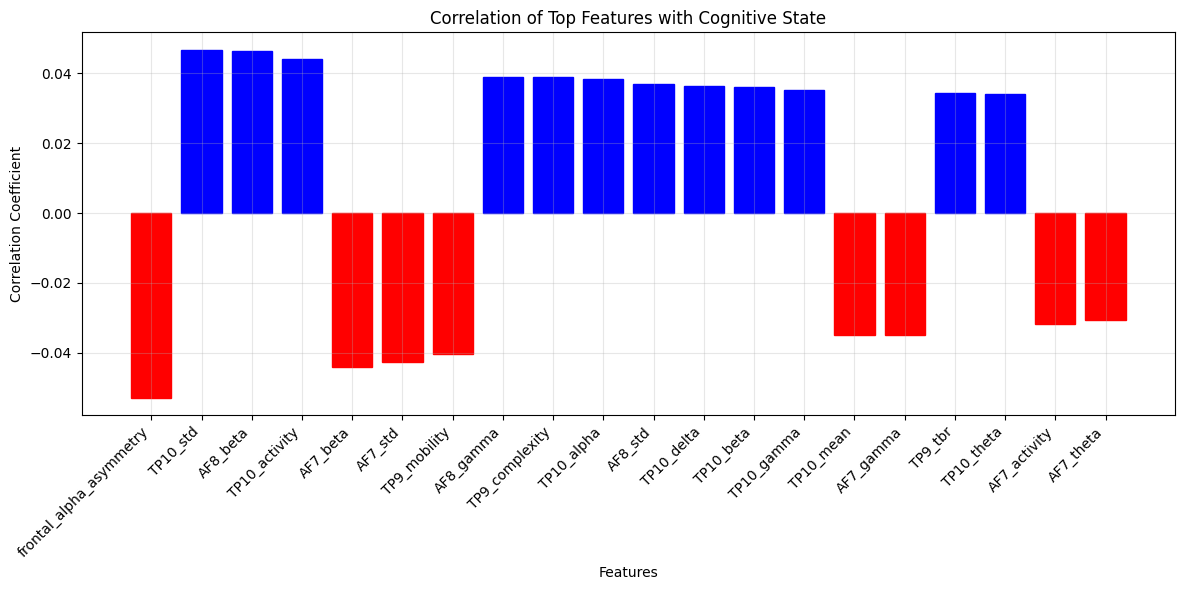

In [ ]:
# Correlation with cognitive states
correlations = []
for i in range(X.shape[1]):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    correlations.append((feature_names[i], abs(corr), corr))

# Sort by absolute correlation
correlations.sort(key=lambda x: x[1], reverse=True)

print("Top 20 features most correlated with cognitive state:")
for name, abs_corr, corr in correlations[:20]:
    print(f'{name}: corr={corr:.3f}, abs={abs_corr:.3f}')

# Correlation heatmap for top features
top_features = [name for name, _, _ in correlations[:20]]
top_indices = [feature_names.index(name) for name in top_features]

# Create correlation matrix
corr_matrix = np.corrcoef(X[:, top_indices].T)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            xticklabels=top_features, yticklabels=top_features)
plt.title('Correlation Matrix: Top 20 Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bar plot of correlations with label
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_features)), [c[2] for c in correlations[:20]])
plt.title('Correlation of Top Features with Cognitive State')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(range(len(top_features)), top_features, rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Color bars by correlation direction
for bar, corr in zip(bars, [c[2] for c in correlations[:20]]):
    bar.set_color('red' if corr < 0 else 'blue')

plt.tight_layout()
plt.show()

## Section 12: Summary and Next Steps

This notebook has explored your processed EEG dataset for cognitive state classification:

- **Dataset**: Samples with 53 features each, labeled into 4 cognitive states
- **Label Distribution**: Fatigued (~25%), Impulsive (~25%), Careful (~25%), Focused (~25%)
- **Feature Analysis**: Theta/beta ratio and alpha power show differences across states
- **Clustering**: PCA and t-SNE reveal some separation between cognitive states

**Key Insights:**
- States are not perfectly balanced - Focused and Careful states are more common
- Frontal alpha asymmetry and theta/beta ratios appear discriminative
- Some clustering is visible in reduced dimensions, suggesting ML models can learn patterns

**Next Steps:**
- Train the three models (Decision Tree, CNN, HMM) on this data
- Evaluate performance and compare approaches
- Consider feature selection or additional physiological signals
- Validate on held-out subjects

Try running all cells and explore the visualizations!